# Temporal Anlaysis of Message distribution

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
# import datasets
df = pd.read_json("../../../Datasets/voluntariosdanavalencia_old.json") # Import data from Voluntarios de Valencia groupchat.

## Distribution of messages (Close to the DANA in time)

In [4]:
# Check data structure
print(df.shape)
print(df.columns)
df.head()

(18064, 17)
Index(['id', 'date', 'message', 'reply_to_msg_id', 'views', 'forwards',
       'edit_date', 'pinned', 'post_author', 'sender_id', 'sender_username',
       'sender_name', 'has_media', 'reactions', 'subgroup', 'topic_name',
       'reply'],
      dtype='object')


,id,date,message,reply_to_msg_id,views,forwards,edit_date,pinned,post_author,sender_id,sender_username,sender_name,has_media,reactions,subgroup,topic_name,reply
0,3,2024-10-30 12:39:24+00:00,Os paso por aquí el correo,NaN,NaN,NaN,None,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,False,[],None,Discusión general,False
1,4,2024-10-30 12:40:50+00:00,LO AVISÉ EL VIERNES PASADO Y NADIE ME HIZO CAS...,NaN,46823.0,1057.0,2024-11-01T18:21:38+00:00,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,True,"[{'user_id': 5887977931, 'username': '', 'disp...",None,Discusión general,False
2,5,2024-10-30 12:43:17+00:00,,NaN,NaN,NaN,2024-11-03T22:44:05+00:00,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,True,"[{'user_id': 6970134793, 'username': '', 'disp...",None,Discusión general,False
3,6,2024-10-30 12:43:23+00:00,Probad si podeis,NaN,NaN,NaN,None,False,NaN,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,False,[],None,Discusión general,False
4,7,2024-10-30 12:46:02+00:00,Durante la tormenta al parecer sí estaba opera...,4.0,NaN,NaN,None,False,NaN,941865373,Camelocota,Víctor Conejero,False,[],Thread_4,Discusión general,True


In [5]:
# Convert date to datetime and sort by time
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"Total messages: {len(df)}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")

Total messages: 18064
Date range: 2024-10-30 12:39:24+00:00 to 2025-11-10 11:06:47+00:00


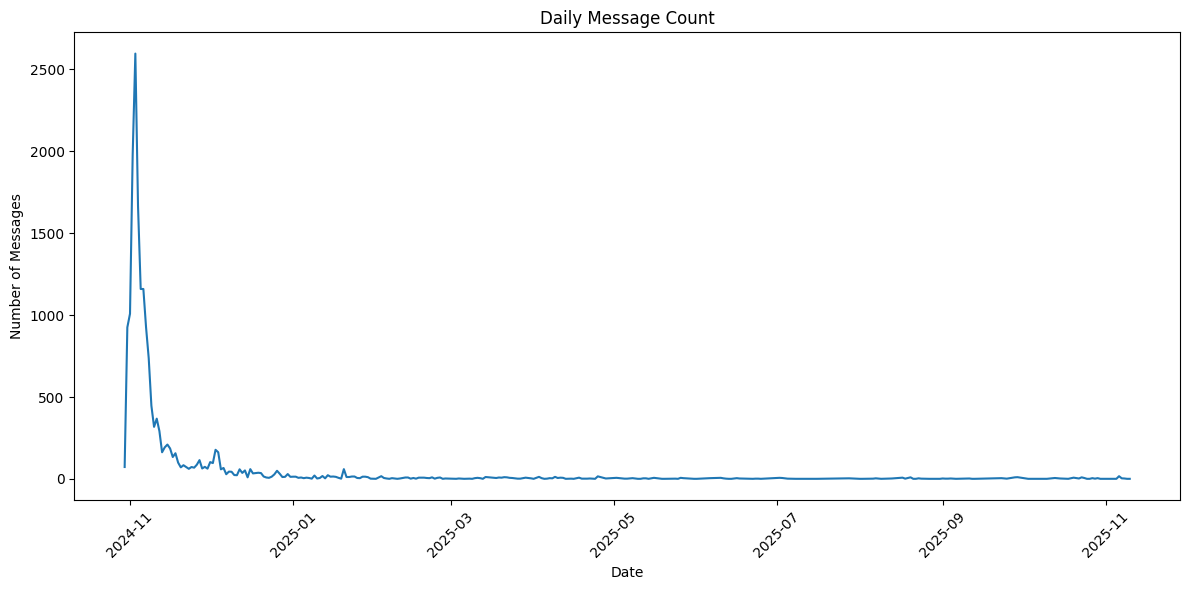

In [6]:
# Plot the distribution of messages over time (daily)
plt.figure(figsize=(12, 6))
df['date_only'] = df['date'].dt.date
daily_counts = df.groupby('date_only').size()
daily_counts.plot(kind='line')
plt.title('Daily Message Count')
plt.xlabel('Date')
plt.ylabel('Number of Messages')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

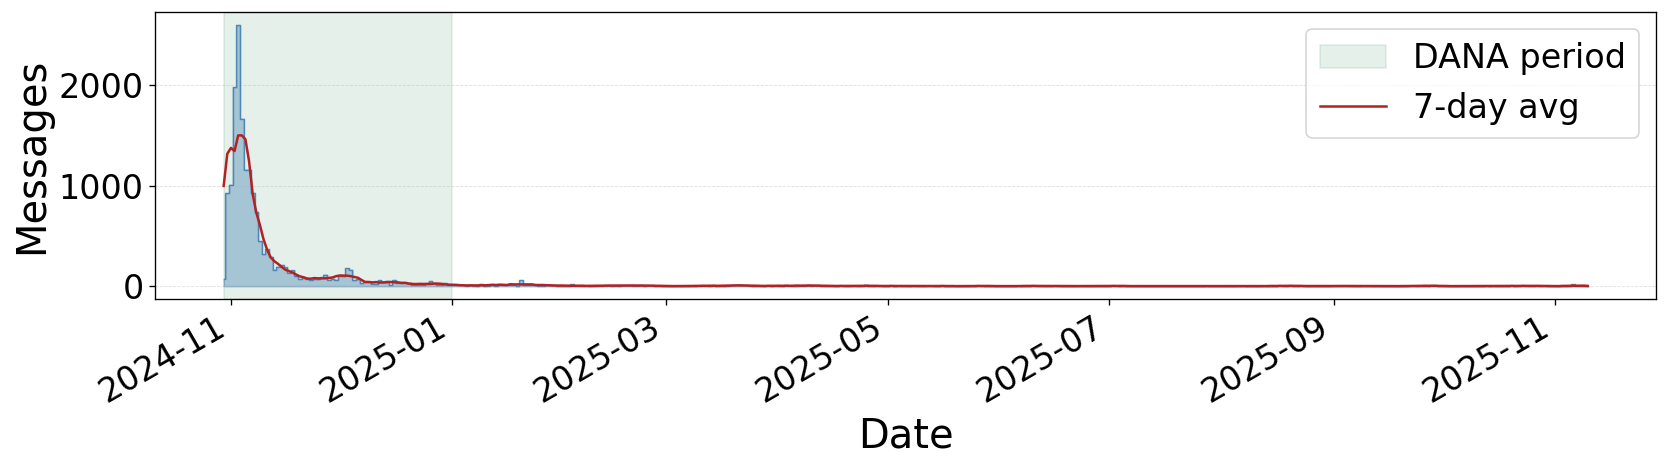

In [10]:
# daily message counts in the community (all channels combined)
df_daily = df.copy()
df_daily["date"] = pd.to_datetime(df_daily["date"], errors="coerce")
df_daily = df_daily.dropna(subset=["date"])
df_daily["day"] = df_daily["date"].dt.normalize()

daily_counts = df_daily.groupby("day").size().rename("n_messages")
# fill missing days with 0
daily_counts = daily_counts.reindex(
    pd.date_range(daily_counts.index.min(), daily_counts.index.max(), freq="D"), fill_value=0
)

with plt.rc_context({"axes.titlesize": 28, "axes.labelsize": 24,
                     "xtick.labelsize": 20, "ytick.labelsize": 20,
                     "legend.fontsize": 20, "figure.dpi": 120}):
    fig, ax = plt.subplots(figsize=(14, 4))

    # ── Studied region: from first message to Jan 1st 2025 ───────────────────
    region_start = daily_counts.index.min()
    region_end   = pd.Timestamp("2025-01-01", tz="UTC")
    ax.axvspan(region_start, region_end,
               color="#2E8B57", alpha=0.12, zorder=0, label="DANA period")

    ax.fill_between(daily_counts.index, daily_counts.values, step="mid",
                    color="steelblue", alpha=0.4)
    ax.step(daily_counts.index, daily_counts.values, where="mid",
            color="steelblue", lw=0.8, alpha=0.9)

    # 7-day rolling average
    rolling = daily_counts.rolling(7, center=True, min_periods=1).mean()
    ax.plot(rolling.index, rolling.values, color="#B22222", lw=1.5, label="7-day avg")

    ax.set_xlabel("Date")
    ax.set_ylabel("Messages")
    ax.legend(loc='upper right')
    ax.grid(axis="y", ls="--", lw=0.5, alpha=0.4)
    fig.autofmt_xdate()
    plt.tight_layout()
    fig.savefig("daily_messages_voluntarios_dana_valencia.pdf", dpi=300, bbox_inches="tight")
    plt.show()


I talked with Emanuele and I could choose the cutoff using an exponential to see when it starts to decay exponentially. Talk to him to do so, right now I will just use January 1st as the cutoff.

In [ ]:
# number of total users in the dataset
total_users = df['sender_id'].nunique()
print(f"Total unique users: {total_users}")

Total unique users: 2539


### Distribution of messages until Jan 1st 2025

Total messages until Jan 1st 2025: 17044
Total messages sent in total (until Nov 10th 2025): 18064
Date range: 2024-10-30 12:39:24+00:00 to 2024-12-31 22:50:08+00:00


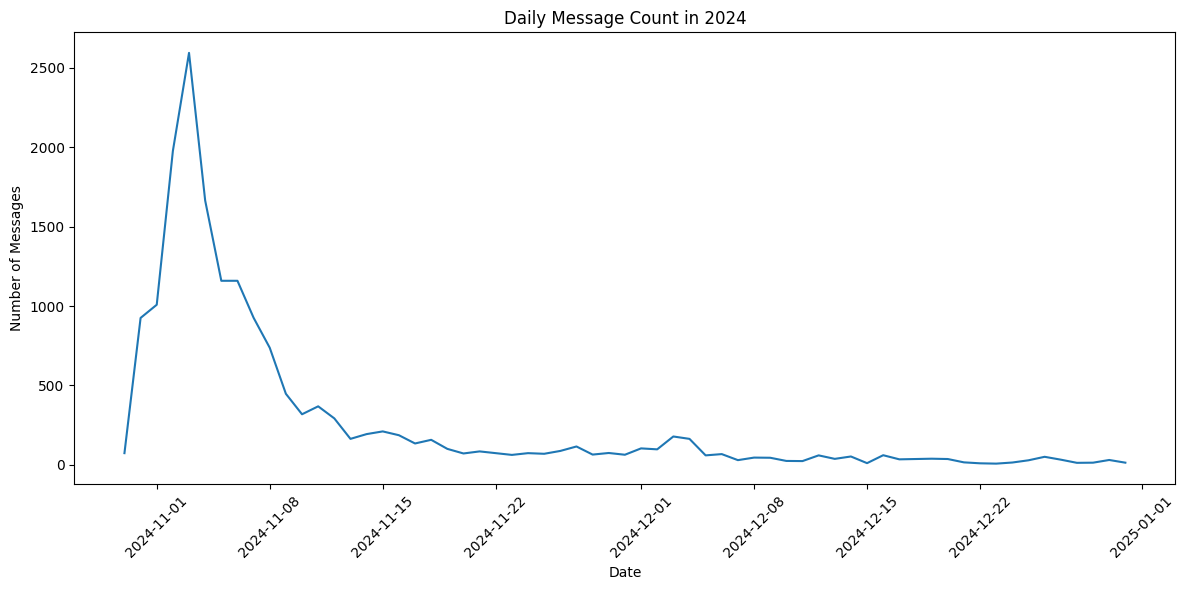

In [ ]:
# Create new dataframe with messages until Jan 1st 2025
df_2024 = df[df['date'] < '2025-01-01'].copy()
print(f"Total messages until Jan 1st 2025: {len(df_2024)}")
print(f"Total messages sent in total (until Nov 10th 2025): {len(df)}")
print(f"Date range: {df_2024['date'].min()} to {df_2024['date'].max()}")

# Plot the distribution of messages over time (daily) for 2024
plt.figure(figsize=(12, 6))
df_2024['date_only'] = df_2024['date'].dt.date
daily_counts_2024 = df_2024.groupby('date_only').size()
daily_counts_2024.plot(kind='line', title='Daily Message Count in 2024')
plt.xlabel('Date')
plt.ylabel('Number of Messages')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

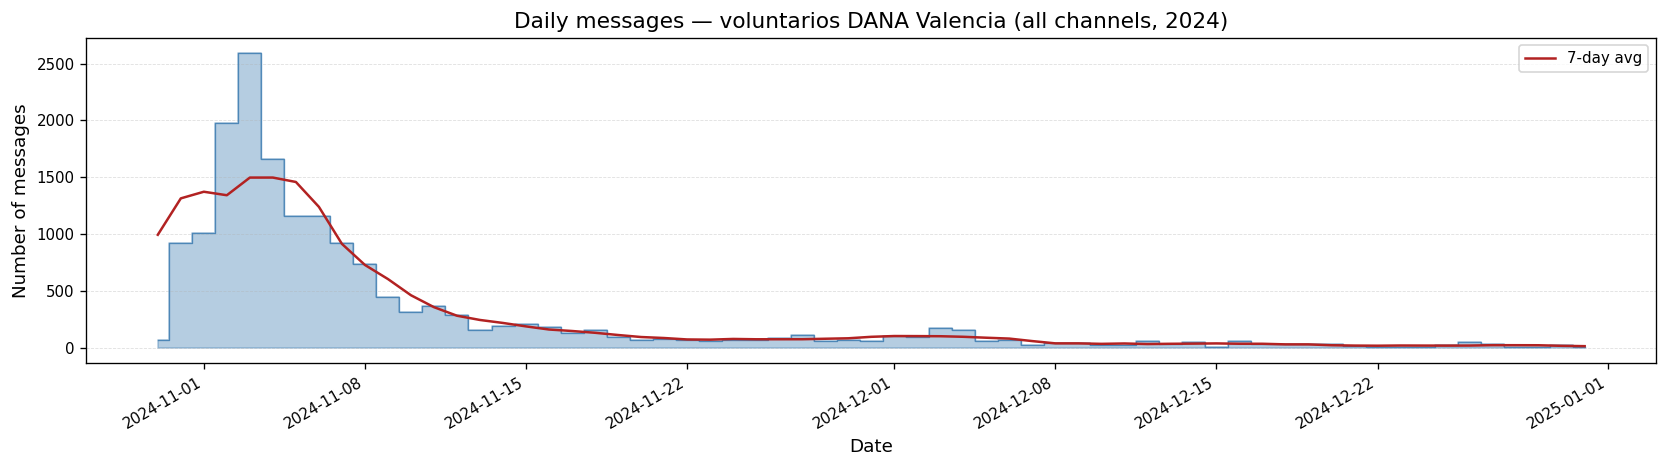

In [ ]:

# daily message counts in the community (all channels combined)
df_daily = df_2024.copy()
df_daily['date'] = pd.to_datetime(df_daily['date'], errors='coerce')
df_daily = df_daily.dropna(subset=['date'])
df_daily['day'] = df_daily['date'].dt.normalize()

daily_counts = df_daily.groupby('day').size().rename('n_messages')
# fill missing days with 0
daily_counts = daily_counts.reindex(
    pd.date_range(daily_counts.index.min(), daily_counts.index.max(), freq='D'), fill_value=0
)

with plt.rc_context({'axes.titlesize': 13, 'axes.labelsize': 11,
                     'xtick.labelsize': 9, 'ytick.labelsize': 9, 'figure.dpi': 120}):
    fig, ax = plt.subplots(figsize=(14, 4))

    ax.fill_between(daily_counts.index, daily_counts.values, step='mid',
                    color='steelblue', alpha=0.4)
    ax.step(daily_counts.index, daily_counts.values, where='mid',
            color='steelblue', lw=0.8, alpha=0.9)

    # 7-day rolling average
    rolling = daily_counts.rolling(7, center=True, min_periods=1).mean()
    ax.plot(rolling.index, rolling.values, color='#B22222', lw=1.5, label='7-day avg')

    ax.set_title('Daily messages — voluntarios DANA Valencia (all channels, 2024)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Number of messages')
    ax.legend(fontsize=9)
    ax.grid(axis='y', ls='--', lw=0.5, alpha=0.4)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


As it can be seen, the major part of the messages were sent in the first three months after the DANA.

In [ ]:
# Calculate waiting times (inter-arrival times) between consecutive messages

# Calculate time differences in seconds
df_2024['waiting_time'] = df_2024['date'].diff().dt.total_seconds()

# Remove the first NaN value and negative values (if any)
waiting_times = df_2024['waiting_time'].dropna()
waiting_times = waiting_times[waiting_times > 0]

print(f"Number of waiting times: {len(waiting_times)}")
print(f"Statistics:")
print(f"  Mean: {waiting_times.mean():.2f} seconds ({waiting_times.mean()/60:.2f} minutes)")
print(f"  Median: {waiting_times.median():.2f} seconds ({waiting_times.median()/60:.2f} minutes)")
print(f"  Min: {waiting_times.min():.2f} seconds")
print(f"  Max: {waiting_times.max():.2f} seconds ({waiting_times.max()/3600:.2f} hours)")

Number of waiting times: 16222
Statistics:
  Mean: 332.48 seconds (5.54 minutes)
  Median: 35.00 seconds (0.58 minutes)
  Min: 1.00 seconds
  Max: 64566.00 seconds (17.93 hours)


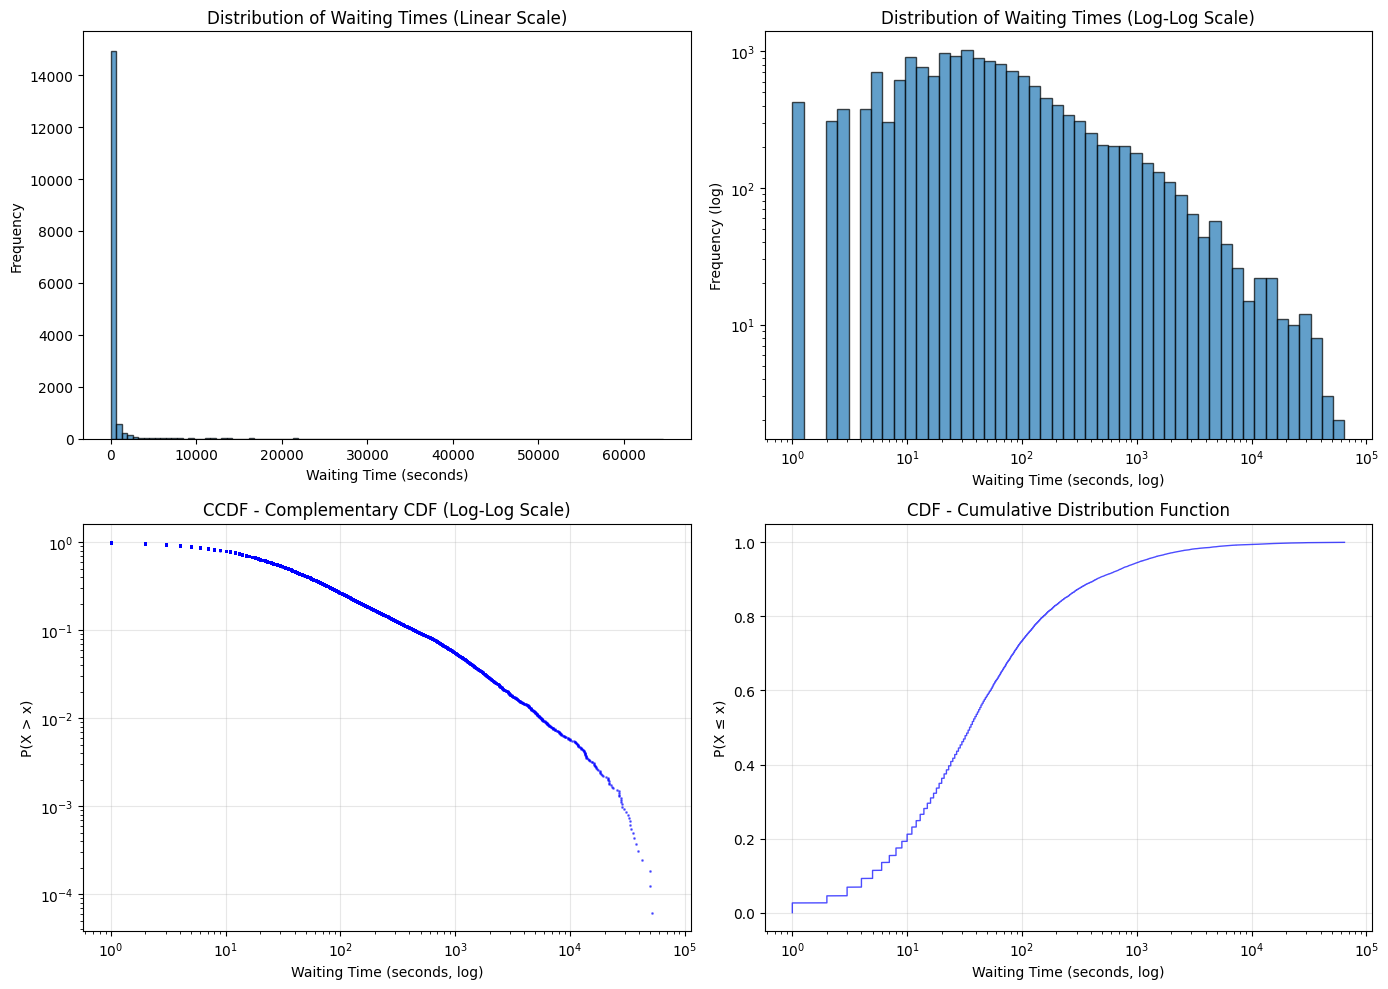

In [ ]:
# Visualize the distribution
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram on linear scale
axes[0, 0].hist(waiting_times, bins=100, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Waiting Time (seconds)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Waiting Times (Linear Scale)')

# Histogram on log-log scale
axes[0, 1].hist(waiting_times, bins=np.logspace(np.log10(waiting_times.min()), 
                                                  np.log10(waiting_times.max()), 50),
                edgecolor='black', alpha=0.7)
axes[0, 1].set_xscale('log')
axes[0, 1].set_yscale('log')
axes[0, 1].set_xlabel('Waiting Time (seconds, log)')
axes[0, 1].set_ylabel('Frequency (log)')
axes[0, 1].set_title('Distribution of Waiting Times (Log-Log Scale)')

# CCDF (Complementary Cumulative Distribution Function) on log-log scale
sorted_times = np.sort(waiting_times)
ccdf = 1 - np.arange(1, len(sorted_times) + 1) / len(sorted_times)
axes[1, 0].plot(sorted_times, ccdf, 'b.', alpha=0.5, markersize=2)
axes[1, 0].set_xscale('log')
axes[1, 0].set_yscale('log')
axes[1, 0].set_xlabel('Waiting Time (seconds, log)')
axes[1, 0].set_ylabel('P(X > x)')
axes[1, 0].set_title('CCDF - Complementary CDF (Log-Log Scale)')
axes[1, 0].grid(True, alpha=0.3)

# CDF
axes[1, 1].plot(sorted_times, np.arange(1, len(sorted_times) + 1) / len(sorted_times), 
                'b-', alpha=0.7, linewidth=1)
axes[1, 1].set_xscale('log')
axes[1, 1].set_xlabel('Waiting Time (seconds, log)')
axes[1, 1].set_ylabel('P(X ≤ x)')
axes[1, 1].set_title('CDF - Cumulative Distribution Function')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Fit to truncated power law

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


TRUNCATED POWER LAW FIT RESULTS
alpha: 1.6055
lambda: 0.000038
xmin: 53.0000
sigma: nan
Data points above xmin: 6535 / 16222 (40.28%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 9.4068, p = 0.0000
  ✓ Truncated power law is significantly better

Truncated PL vs Lognormal:
  R = 4.2504, p = 0.0000
  ✓ Truncated power law is significantly better

Truncated PL vs Exponential:
  R = 22.9280, p = 0.0000
  ✓ Truncated power law is significantly better


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')



KS distance (truncated power law): 0.0118
✓ Good fit (KS < 0.1)


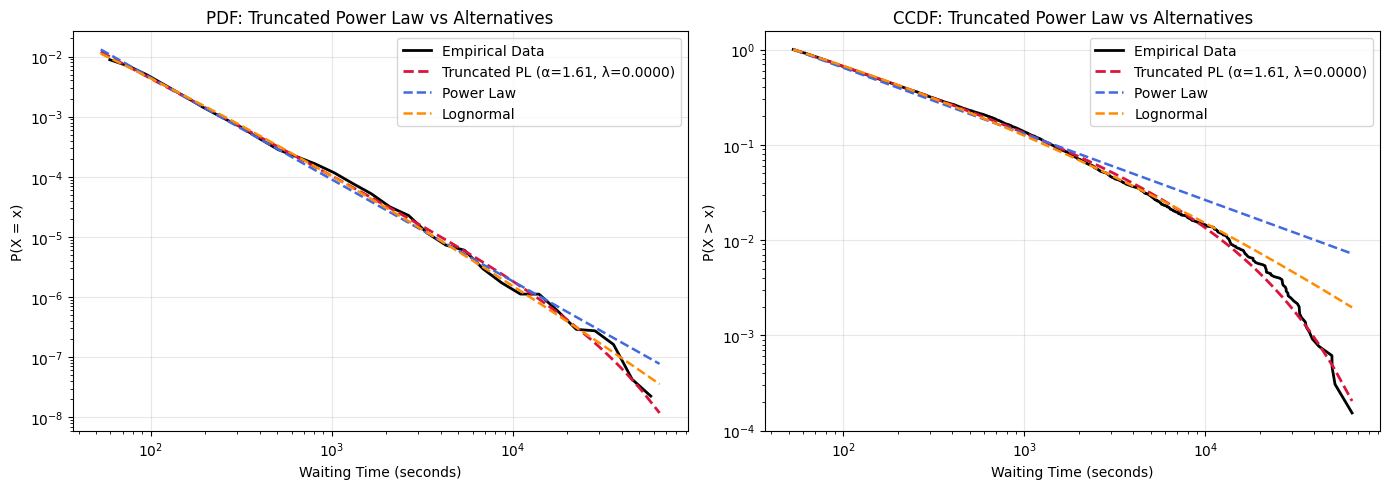

KS statistic (tail): 0.011921
KS p-value (tail): 0.308531


In [ ]:
import powerlaw

# Prepare data
data_tpl = np.asarray(waiting_times.values, dtype=float)
data_tpl = data_tpl[np.isfinite(data_tpl)]
data_tpl = data_tpl[data_tpl > 0]

# Fit using powerlaw package
fit_tpl = powerlaw.Fit(data_tpl, discrete=False, verbose=False)
tpl = fit_tpl.truncated_power_law

alpha_tpl = getattr(tpl, "alpha", np.nan)
lambda_tpl = getattr(tpl, "Lambda", np.nan)
xmin_tpl = getattr(tpl, "xmin", np.nan)
sigma_tpl = getattr(tpl, "sigma", np.nan)

print("="*70)
print("TRUNCATED POWER LAW FIT RESULTS")
print("="*70)
print(f"alpha: {alpha_tpl:.4f}")
print(f"lambda: {lambda_tpl:.6f}")
print(f"xmin: {xmin_tpl:.4f}")
print(f"sigma: {sigma_tpl:.4f}")
n_tail_tpl = int(np.sum(data_tpl >= xmin_tpl))
print(f"Data points above xmin: {n_tail_tpl} / {len(data_tpl)} ({100 * n_tail_tpl / len(data_tpl):.2f}%)")

# Likelihood-ratio comparisons (positive R => first model preferred)
print("\n" + "="*70)
print("TRUNCATED POWER LAW COMPARISONS")
print("="*70)
comparisons = [
    ("truncated_power_law", "power_law", "Truncated PL vs Power Law"),
    ("truncated_power_law", "lognormal", "Truncated PL vs Lognormal"),
    ("truncated_power_law", "exponential", "Truncated PL vs Exponential"),
]

for d1, d2, label in comparisons:
    R, p = fit_tpl.distribution_compare(d1, d2, normalized_ratio=True)
    print(f"\n{label}:")
    print(f"  R = {R:.4f}, p = {p:.4f}")
    if p < 0.05:
        if R > 0:
            print("  ✓ Truncated power law is significantly better")
        else:
            print(f"  ✗ {d2.replace('_', ' ')} is significantly better")
    else:
        print("  ≈ No significant difference")

# Manual KS distance for truncated power law
tail_tpl = np.sort(data_tpl[data_tpl >= xmin_tpl])
if len(tail_tpl) == 0:
    ks_tpl = float("nan")
else:
    empirical_cdf_tpl = np.arange(1, len(tail_tpl) + 1) / len(tail_tpl)
    try:
        model_cdf_tpl = tpl.cdf(tail_tpl)
    except Exception:
        model_cdf_tpl = 1 - tpl.ccdf(tail_tpl)
    ks_tpl = np.max(np.abs(empirical_cdf_tpl - model_cdf_tpl))

print("\n" + "="*70)
print(f"KS distance (truncated power law): {ks_tpl:.4f}")
if np.isnan(ks_tpl):
    print("KS could not be computed (no data >= xmin).")
elif ks_tpl < 0.1:
    print("✓ Good fit (KS < 0.1)")
elif ks_tpl < 0.15:
    print("~ Moderate fit (0.1 ≤ KS < 0.15)")
else:
    print("✗ Poor fit (KS ≥ 0.15)")
print("="*70)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fit_tpl.plot_pdf(color='black', linewidth=2, label='Empirical Data', ax=axes[0])
tpl.plot_pdf(
    color='crimson', linestyle='--', linewidth=2,
    label=f'Truncated PL (α={alpha_tpl:.2f}, λ={lambda_tpl:.4f})', ax=axes[0]
 )
fit_tpl.power_law.plot_pdf(color='royalblue', linestyle='--', linewidth=1.8, label='Power Law', ax=axes[0])
fit_tpl.lognormal.plot_pdf(color='darkorange', linestyle='--', linewidth=1.8, label='Lognormal', ax=axes[0])
axes[0].set_xlabel('Waiting Time (seconds)')
axes[0].set_ylabel('P(X = x)')
axes[0].set_title('PDF: Truncated Power Law vs Alternatives')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

fit_tpl.plot_ccdf(color='black', linewidth=2, label='Empirical Data', ax=axes[1])
tpl.plot_ccdf(
    color='crimson', linestyle='--', linewidth=2,
    label=f'Truncated PL (α={alpha_tpl:.2f}, λ={lambda_tpl:.4f})', ax=axes[1]
 )
fit_tpl.power_law.plot_ccdf(color='royalblue', linestyle='--', linewidth=1.8, label='Power Law', ax=axes[1])
fit_tpl.lognormal.plot_ccdf(color='darkorange', linestyle='--', linewidth=1.8, label='Lognormal', ax=axes[1])
axes[1].set_xlabel('Waiting Time (seconds)')
axes[1].set_ylabel('P(X > x)')
axes[1].set_title('CCDF: Truncated Power Law vs Alternatives')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# One-off: compute KS p-value for truncated power law tail fit
from scipy import stats

tail_tpl = np.sort(data_tpl[data_tpl >= xmin_tpl])
ks_stat_tpl, ks_p_tpl = stats.kstest(tail_tpl, tpl.cdf)
print("="*70)
print(f"KS statistic (tail): {ks_stat_tpl:.6f}")
print(f"KS p-value (tail): {ks_p_tpl:.6g}")
print("="*70)

In [ ]:
# Bootstrap uncertainty estimates for alpha and lambda (truncated power law)
import numpy as np
import powerlaw

# Reuse cleaned data from previous fit cell if available
if 'data_tpl' not in globals():
    data_tpl = np.asarray(waiting_times.values, dtype=float)
    data_tpl = data_tpl[np.isfinite(data_tpl)]
    data_tpl = data_tpl[data_tpl > 0]

rng = np.random.default_rng(87)
n_boot = 120  # increase to 300+ for tighter CIs (slower)

alpha_boot = []
lambda_boot = []

for _ in range(n_boot):
    sample = rng.choice(data_tpl, size=len(data_tpl), replace=True)
    try:
        fit_b = powerlaw.Fit(sample, discrete=False, verbose=False)
        tpl_b = fit_b.truncated_power_law
        a = float(getattr(tpl_b, 'alpha', np.nan))
        l = float(getattr(tpl_b, 'Lambda', np.nan))
        if np.isfinite(a) and np.isfinite(l):
            alpha_boot.append(a)
            lambda_boot.append(l)
    except Exception:
        continue

alpha_boot = np.asarray(alpha_boot, dtype=float)
lambda_boot = np.asarray(lambda_boot, dtype=float)

if alpha_boot.size < 30 or lambda_boot.size < 30:
    print(f"Too few successful bootstrap fits: alpha={alpha_boot.size}, lambda={lambda_boot.size}")
else:
    alpha_se = np.std(alpha_boot, ddof=1)
    lambda_se = np.std(lambda_boot, ddof=1)

    alpha_ci = np.percentile(alpha_boot, [2.5, 97.5])
    lambda_ci = np.percentile(lambda_boot, [2.5, 97.5])

    print('='*70)
    print('BOOTSTRAP UNCERTAINTY (Truncated Power Law)')
    print('='*70)
    print(f"Successful bootstrap fits: {alpha_boot.size}/{n_boot}")
    print(f"alpha estimate:  {alpha_tpl:.6f} +/- {alpha_se:.6f} (SE)")
    print(f"alpha 95% CI:    [{alpha_ci[0]:.6f}, {alpha_ci[1]:.6f}]")
    print(f"lambda estimate: {lambda_tpl:.8f} +/- {lambda_se:.8f} (SE)")
    print(f"lambda 95% CI:   [{lambda_ci[0]:.8f}, {lambda_ci[1]:.8f}]")
    print('='*70)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively c

BOOTSTRAP UNCERTAINTY (Truncated Power Law)
Successful bootstrap fits: 120/120
alpha estimate:  1.605495 +/- 0.086023 (SE)
alpha 95% CI:    [1.581071, 1.885179]
lambda estimate: 0.00003758 +/- 0.00000866 (SE)
lambda 95% CI:   [0.00001337, 0.00004924]


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


In [ ]:
# Clauset et al. (2009) semiparametric bootstrap p-value for TPL goodness-of-fit
# Algorithm (Section 4.2 of Clauset et al.):
#   1. Fit TPL -> xmin, alpha, lambda, empirical KS statistic D_emp
#   2. For each bootstrap:
#      a. Draw n_below values below xmin from the empirical data (resample)
#      b. Draw n_tail values above xmin from the fitted TPL (acceptance-rejection)
#      c. Fit TPL to the synthetic dataset -> D_boot
#   3. p = fraction of D_boot >= D_emp
import numpy as np
import powerlaw
from scipy.stats import kstest

def _sample_tpl(n, xmin, alpha, lam, rng, max_rounds=50):
    samples = []
    for _ in range(max_rounds):
        need = n - len(samples)
        if need <= 0:
            break
        u = rng.uniform(size=need * 5)
        t = xmin * u ** (-1.0 / (alpha - 1.0))       # Pareto proposal
        accept = rng.uniform(size=len(t)) < np.exp(-lam * (t - xmin))
        samples.extend(t[accept].tolist())
    return np.array(samples[:n])


def _tpl_ks(data, xmin, alpha, lam):
    tail = data[data >= xmin]
    if len(tail) == 0:
        return np.nan
    def cdf(t):
        s = (t / xmin) ** (-(alpha - 1)) * np.exp(-(t - xmin) * lam)
        return 1.0 - np.clip(s, 0.0, 1.0)
    return kstest(tail, cdf).statistic


def clauset_tpl_pvalue(data, n_bootstrap=1000, discrete=False, seed=42):
    rng  = np.random.default_rng(seed)
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data) & (data > 0)]

    fit  = powerlaw.Fit(data, discrete=discrete, verbose=False)
    tpl  = fit.truncated_power_law
    xmin  = float(getattr(tpl, 'xmin',   fit.xmin))
    alpha = float(getattr(tpl, 'alpha',   np.nan))
    lam   = float(getattr(tpl, 'Lambda',  np.nan))

    if not all(np.isfinite([xmin, alpha, lam])):
        print("TPL fit on empirical data failed.")
        return np.nan, np.nan

    D_emp   = _tpl_ks(data, xmin, alpha, lam)
    below   = data[data < xmin]
    n_below = len(below)
    n_tail  = int(np.sum(data >= xmin))

    print(f"Empirical: xmin={xmin:.1f}, alpha={alpha:.4f}, lambda={lam:.6f}")
    print(f"  n_tail={n_tail}, n_below={n_below}, D_emp={D_emp:.4f}")
    print(f"  Running {n_bootstrap} bootstrap samples (this may take a minute)...")

    boot_ks = []
    for b in range(n_bootstrap):
        syn_below = rng.choice(below, size=n_below, replace=True) if n_below > 0 else np.array([])
        syn_tail  = _sample_tpl(n_tail, xmin, alpha, lam, rng)
        if len(syn_tail) < n_tail:
            continue
        syn = np.concatenate([syn_below, syn_tail])
        try:
            fb   = powerlaw.Fit(syn, discrete=discrete, verbose=False)
            tb   = fb.truncated_power_law
            xb   = float(getattr(tb, 'xmin',  fb.xmin))
            ab   = float(getattr(tb, 'alpha',  np.nan))
            lb   = float(getattr(tb, 'Lambda', np.nan))
            if all(np.isfinite([xb, ab, lb])):
                D_b = _tpl_ks(syn, xb, ab, lb)
                if np.isfinite(D_b):
                    boot_ks.append(D_b)
        except Exception:
            continue
        if (b + 1) % 200 == 0:
            print(f"  {b+1}/{n_bootstrap} done...")

    boot_ks = np.array(boot_ks)
    p = np.mean(boot_ks >= D_emp)
    stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '(n.s.)'
    print(f"\nClauset bootstrap p-value: {p:.4f}  {stars}")
    print(f"  ({len(boot_ks)}/{n_bootstrap} successful bootstraps)")
    print(f"  Interpretation: {'TPL is a plausible fit' if p >= 0.1 else 'TPL fit is NOT plausible (p < 0.1)'}")
    return p, D_emp


In [ ]:
# Clauset et al. bootstrap p-value — until Jan. 1st 2025
print("=" * 60)
print("CLAUSET BOOTSTRAP — until Jan. 1st 2025")
print("=" * 60)
p_clauset_2024, D_2024 = clauset_tpl_pvalue(data_tpl, n_bootstrap=1000, discrete=False)


CLAUSET BOOTSTRAP — until Jan. 1st 2025


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


Empirical: xmin=53.0, alpha=1.6055, lambda=0.000038
  n_tail=6535, n_below=9687, D_emp=0.0329
  Running 1000 bootstrap samples (this may take a minute)...


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges

  200/1000 done...


...

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges

  800/1000 done...


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges

  1000/1000 done...

Clauset bootstrap p-value: 0.6860  (n.s.)
  (1000/1000 successful bootstraps)
  Interpretation: TPL is a plausible fit


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


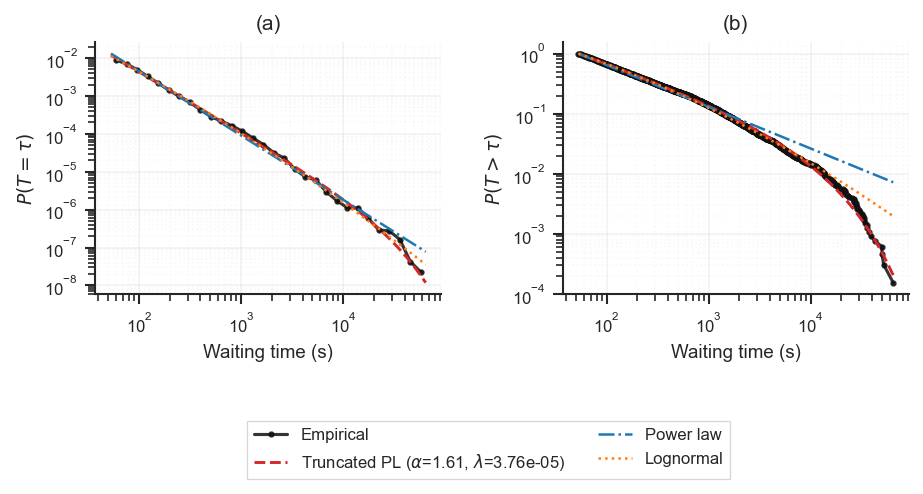

In [ ]:
# Paper-ready visualization: Truncated power law vs alternatives
import seaborn as sns
from matplotlib.ticker import LogLocator, LogFormatterMathtext
import matplotlib as mpl

sns.set_theme(style="ticks", context="paper")
mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

palette = {
    "empirical": "#111111",
    "tpl": "#D62728",
    "pl": "#1F77B4",
    "ln": "#FF7F0E",
}

fig, axes = plt.subplots(1, 2, figsize=(7, 2.8))

# --- PDF panel ---
fit_tpl.plot_pdf(
    color=palette["empirical"], linewidth=1.5, marker='o', markersize=2, alpha=0.85,
    label="Empirical", ax=axes[0]
 )
tpl.plot_pdf(
    color=palette["tpl"], linestyle='--', linewidth=1.4,
    label=rf"Truncated PL ($\alpha$={alpha_tpl:.2f}, $\lambda$={lambda_tpl:.2e})", ax=axes[0]
 )
fit_tpl.power_law.plot_pdf(
    color=palette["pl"], linestyle='-.', linewidth=1.2, label="Power law", ax=axes[0]
 )
fit_tpl.lognormal.plot_pdf(
    color=palette["ln"], linestyle=':', linewidth=1.2, label="Lognormal", ax=axes[0]
 )

#axes[0].set_title("Probability Density Function", pad=6)
axes[0].set_title("(a)", pad=6)
axes[0].set_xlabel("Waiting time (s)")
axes[0].set_ylabel(r"$P(T=\tau)$")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].xaxis.set_major_locator(LogLocator(base=10))
axes[0].yaxis.set_major_locator(LogLocator(base=10))
axes[0].xaxis.set_major_formatter(LogFormatterMathtext())
axes[0].yaxis.set_major_formatter(LogFormatterMathtext())
axes[0].grid(which="major", alpha=0.25, linestyle='-')
axes[0].grid(which="minor", alpha=0.12, linestyle=':')

# --- CCDF panel ---
fit_tpl.plot_ccdf(
    color=palette["empirical"], linewidth=1.5, marker='o', markersize=2, alpha=0.85,
    label="Empirical", ax=axes[1]
 )
tpl.plot_ccdf(
    color=palette["tpl"], linestyle='--', linewidth=1.4,
    label=rf"Truncated PL ($\alpha$={alpha_tpl:.2f}, $\lambda$={lambda_tpl:.2e})", ax=axes[1]
 )
fit_tpl.power_law.plot_ccdf(
    color=palette["pl"], linestyle='-.', linewidth=1.2, label="Power law", ax=axes[1]
 )
fit_tpl.lognormal.plot_ccdf(
    color=palette["ln"], linestyle=':', linewidth=1.2, label="Lognormal", ax=axes[1]
 )

#axes[1].set_title("Complementary CDF", pad=6)
axes[1].set_title("(b)", pad=6)
axes[1].set_xlabel("Waiting time (s)")
axes[1].set_ylabel(r"$P(T>\tau)$")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].xaxis.set_major_locator(LogLocator(base=10))
axes[1].yaxis.set_major_locator(LogLocator(base=10))
axes[1].xaxis.set_major_formatter(LogFormatterMathtext())
axes[1].yaxis.set_major_formatter(LogFormatterMathtext())
axes[1].grid(which="major", alpha=0.25, linestyle='-')
axes[1].grid(which="minor", alpha=0.12, linestyle=':')

# Shared legend below both panels
handles, labels = axes[1].get_legend_handles_labels()
legend = fig.legend(
    handles, labels, ncol=2, loc="lower center", bbox_to_anchor=(0.5, -0.18),
    frameon=True, fancybox=False, edgecolor="0.8"
 )
legend.get_frame().set_linewidth(0.6)

fig.subplots_adjust(bottom=0.28, wspace=0.35)

fig.savefig("paper_waiting_time_fit.pdf", format="pdf", bbox_inches="tight")

plt.show()

## Waiting times for the two weeks after the DANA

Here we will only consider messages until 2 weeks after the rain on Oct. 29th 2024 (Nov. 12 2024)

Total messages during first two weeks: 13649
Total messages sent in total (until Nov 10th 2025): 18064
Date range: 2024-10-30 12:39:24+00:00 to 2024-11-12 23:41:24+00:00


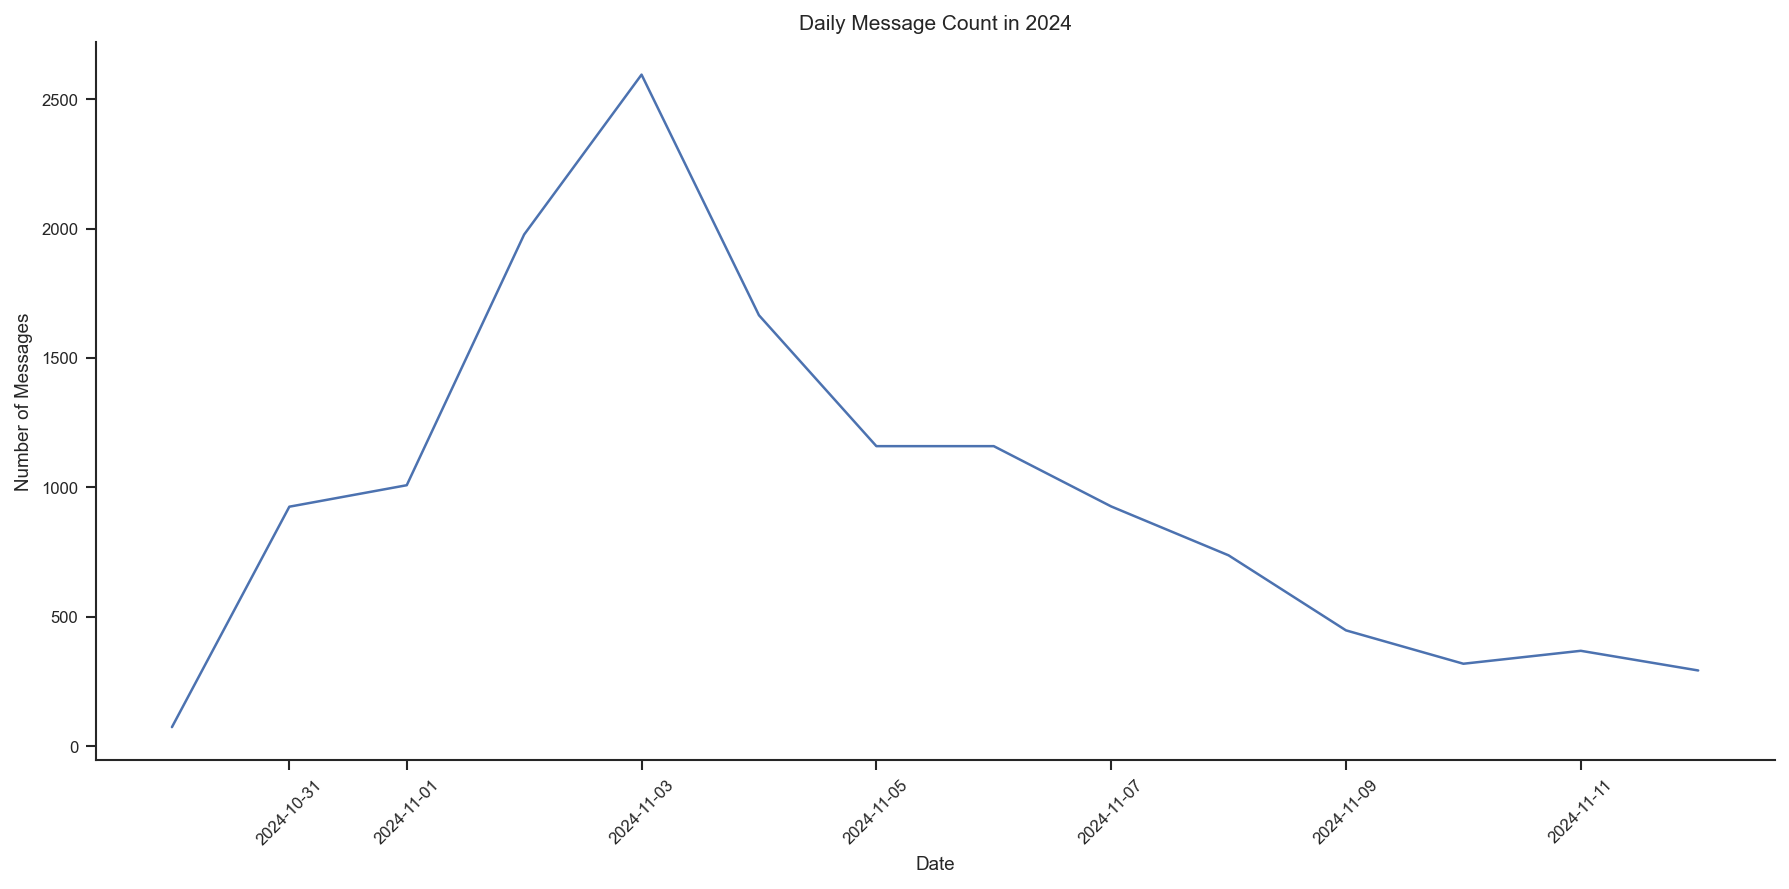

In [ ]:
# Create new dataframe with messages during the first two weeks (until Nov. 12th 2024)
df_twoweeks = df[df['date'] < '2024-11-13'].copy()
print(f"Total messages during first two weeks: {len(df_twoweeks)}")
print(f"Total messages sent in total (until Nov 10th 2025): {len(df)}")
print(f"Date range: {df_twoweeks['date'].min()} to {df_twoweeks['date'].max()}")

# Plot the distribution of messages over time (daily) for 2024
plt.figure(figsize=(12, 6))
df_2024['date_only'] = df_twoweeks['date'].dt.date
daily_counts_2024 = df_2024.groupby('date_only').size()
daily_counts_2024.plot(kind='line', title='Daily Message Count in 2024')
plt.xlabel('Date')
plt.ylabel('Number of Messages')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Calculate time differences in seconds
df_twoweeks['waiting_time'] = df_twoweeks['date'].diff().dt.total_seconds()

# Remove the first NaN value and negative values (if any)
waiting_times_w = df_twoweeks['waiting_time'].dropna()
waiting_times_w = waiting_times_w[waiting_times_w > 0]

print(f"Number of waiting times: {len(waiting_times_w)}")
print(f"Statistics:")
print(f"  Mean: {waiting_times_w.mean():.2f} seconds ({waiting_times_w.mean()/60:.2f} minutes)")
print(f"  Median: {waiting_times_w.median():.2f} seconds ({waiting_times_w.median()/60:.2f} minutes)")
print(f"  Min: {waiting_times_w.min():.2f} seconds")
print(f"  Max: {waiting_times_w.max():.2f} seconds ({waiting_times_w.max()/3600:.2f} hours)")

Number of waiting times: 12983
Statistics:
  Mean: 89.57 seconds (1.49 minutes)
  Median: 27.00 seconds (0.45 minutes)
  Min: 1.00 seconds
  Max: 26854.00 seconds (7.46 hours)


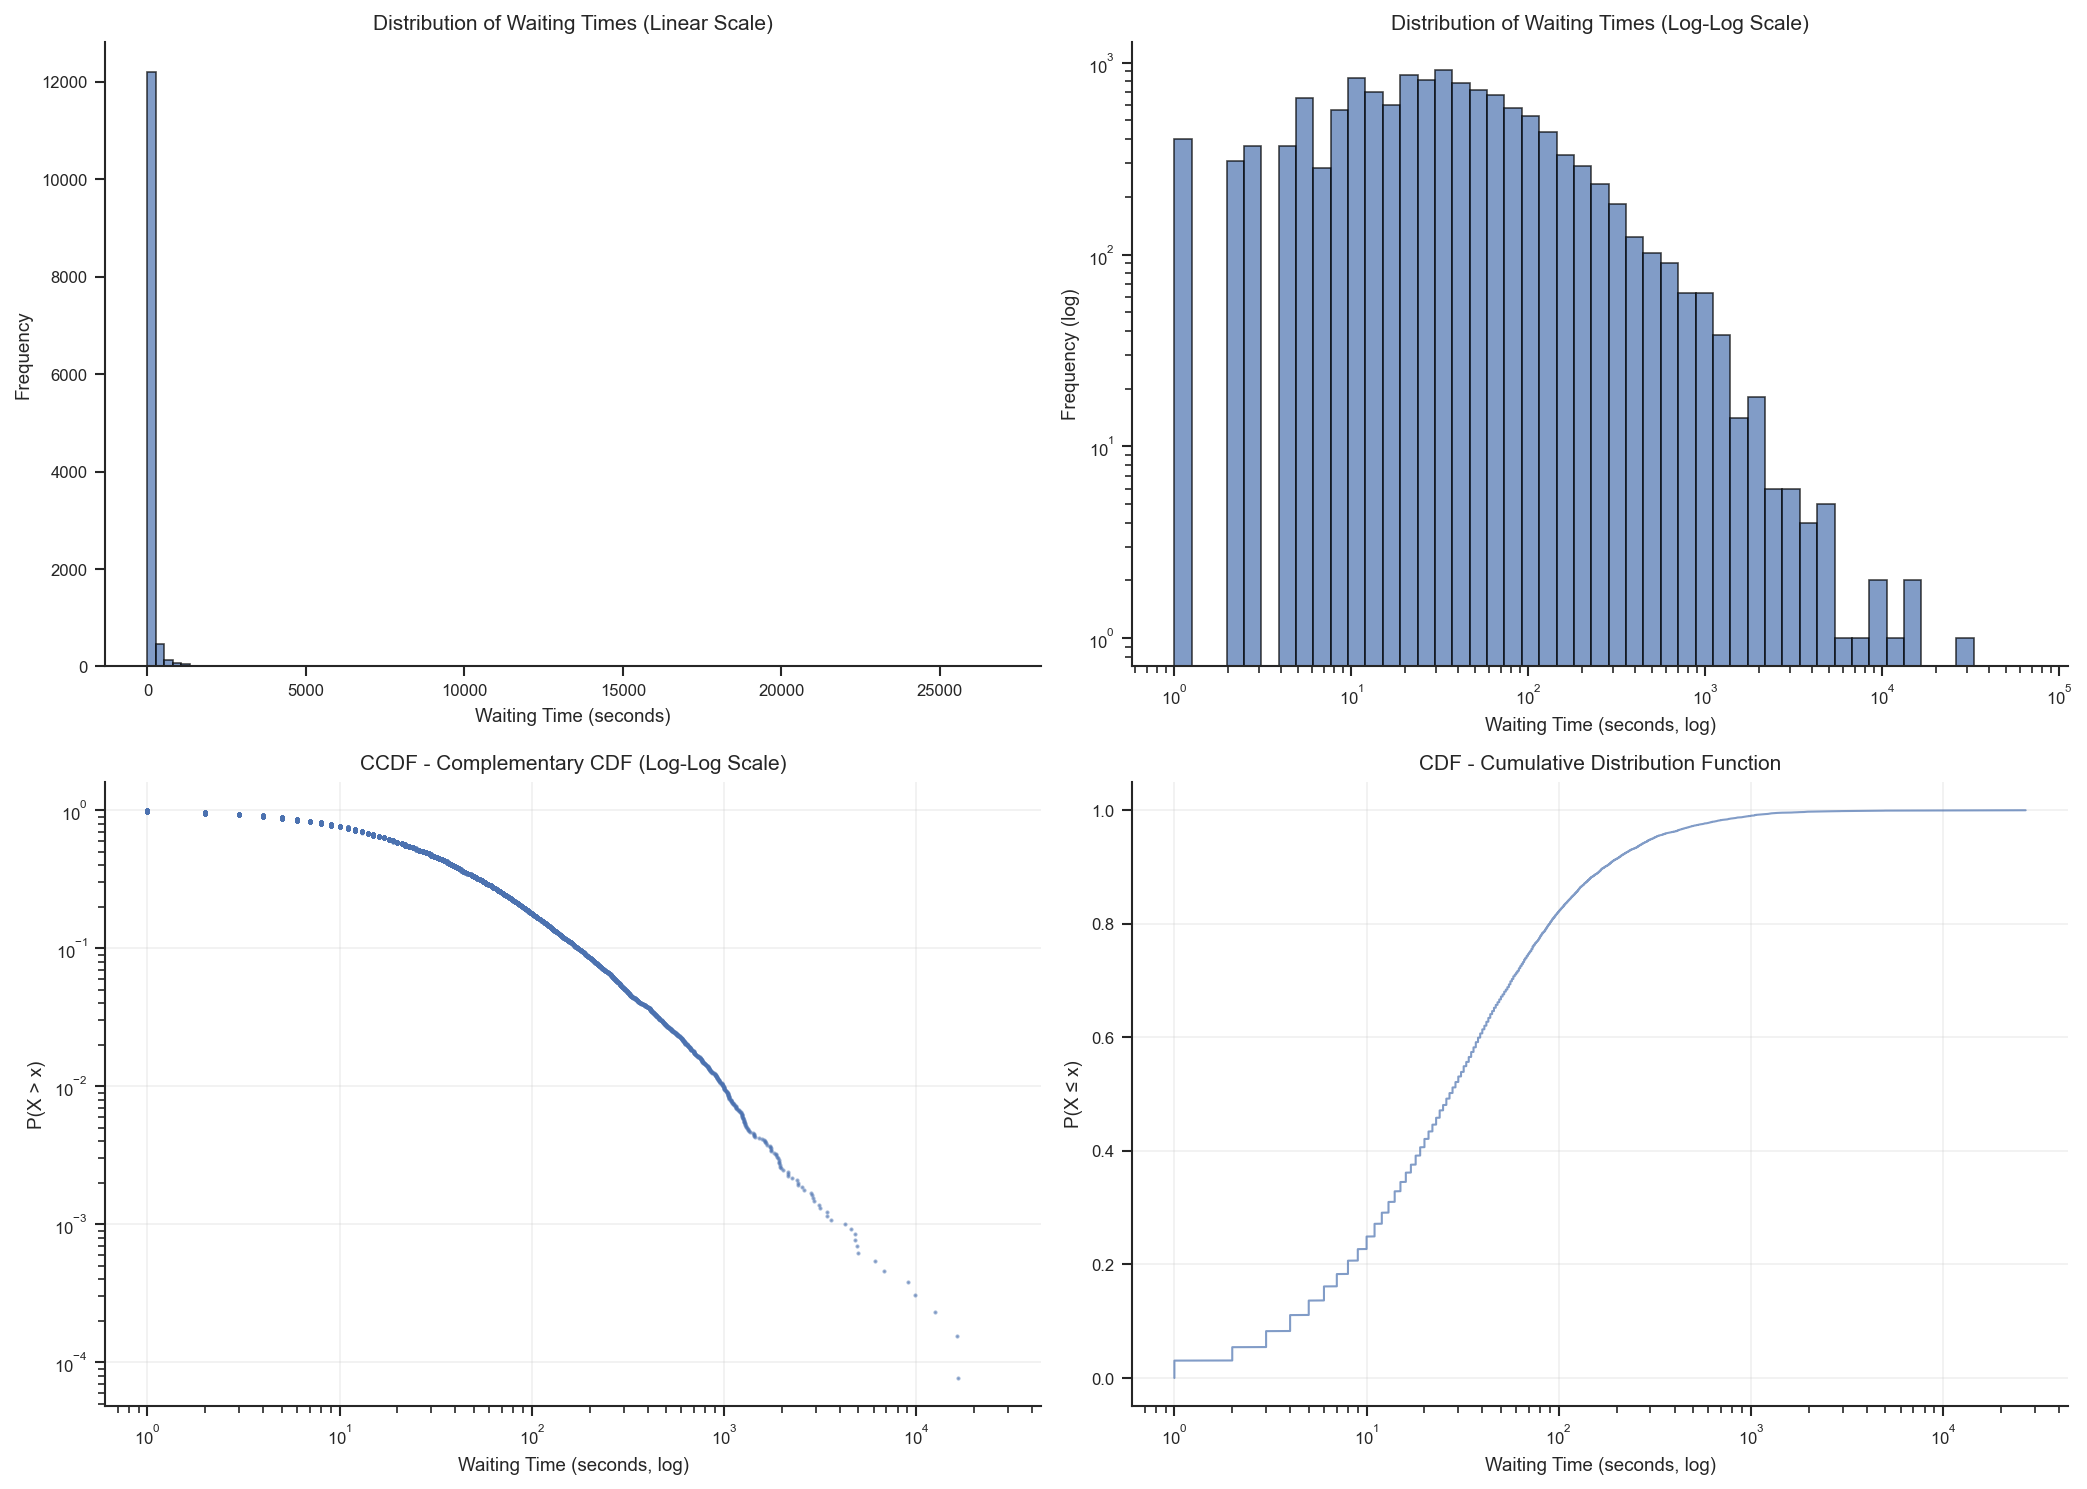

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram on linear scale
axes[0, 0].hist(waiting_times_w, bins=100, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Waiting Time (seconds)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Waiting Times (Linear Scale)')

# Histogram on log-log scale
axes[0, 1].hist(waiting_times_w, bins=np.logspace(np.log10(waiting_times.min()), 
                                                  np.log10(waiting_times.max()), 50),
                edgecolor='black', alpha=0.7)
axes[0, 1].set_xscale('log')
axes[0, 1].set_yscale('log')
axes[0, 1].set_xlabel('Waiting Time (seconds, log)')
axes[0, 1].set_ylabel('Frequency (log)')
axes[0, 1].set_title('Distribution of Waiting Times (Log-Log Scale)')

# CCDF (Complementary Cumulative Distribution Function) on log-log scale
sorted_times_w = np.sort(waiting_times_w)
ccdf = 1 - np.arange(1, len(sorted_times_w) + 1) / len(sorted_times_w)
axes[1, 0].plot(sorted_times_w, ccdf, 'b.', alpha=0.5, markersize=2)
axes[1, 0].set_xscale('log')
axes[1, 0].set_yscale('log')
axes[1, 0].set_xlabel('Waiting Time (seconds, log)')
axes[1, 0].set_ylabel('P(X > x)')
axes[1, 0].set_title('CCDF - Complementary CDF (Log-Log Scale)')
axes[1, 0].grid(True, alpha=0.3)

# CDF
axes[1, 1].plot(sorted_times_w, np.arange(1, len(sorted_times_w) + 1) / len(sorted_times_w), 
                'b-', alpha=0.7, linewidth=1)
axes[1, 1].set_xscale('log')
axes[1, 1].set_xlabel('Waiting Time (seconds, log)')
axes[1, 1].set_ylabel('P(X ≤ x)')
axes[1, 1].set_title('CDF - Cumulative Distribution Function')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Truncated power law fit

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'

TRUNCATED POWER LAW FIT RESULTS
alpha: 2.0037
lambda: 0.000176
xmin: 78.0000
sigma: nan
Data points above xmin: 2991 / 12983 (23.04%)

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Power Law:
  R = 2.4539, p = 0.0000
  ✓ Truncated power law is significantly better

Truncated PL vs Lognormal:
  R = -1.9832, p = 0.0473
  ✗ lognormal is significantly better

Truncated PL vs Exponential:
  R = 6.4133, p = 0.0000
  ✓ Truncated power law is significantly better

KS distance (truncated power law): 0.0192
✓ Good fit (KS < 0.1)


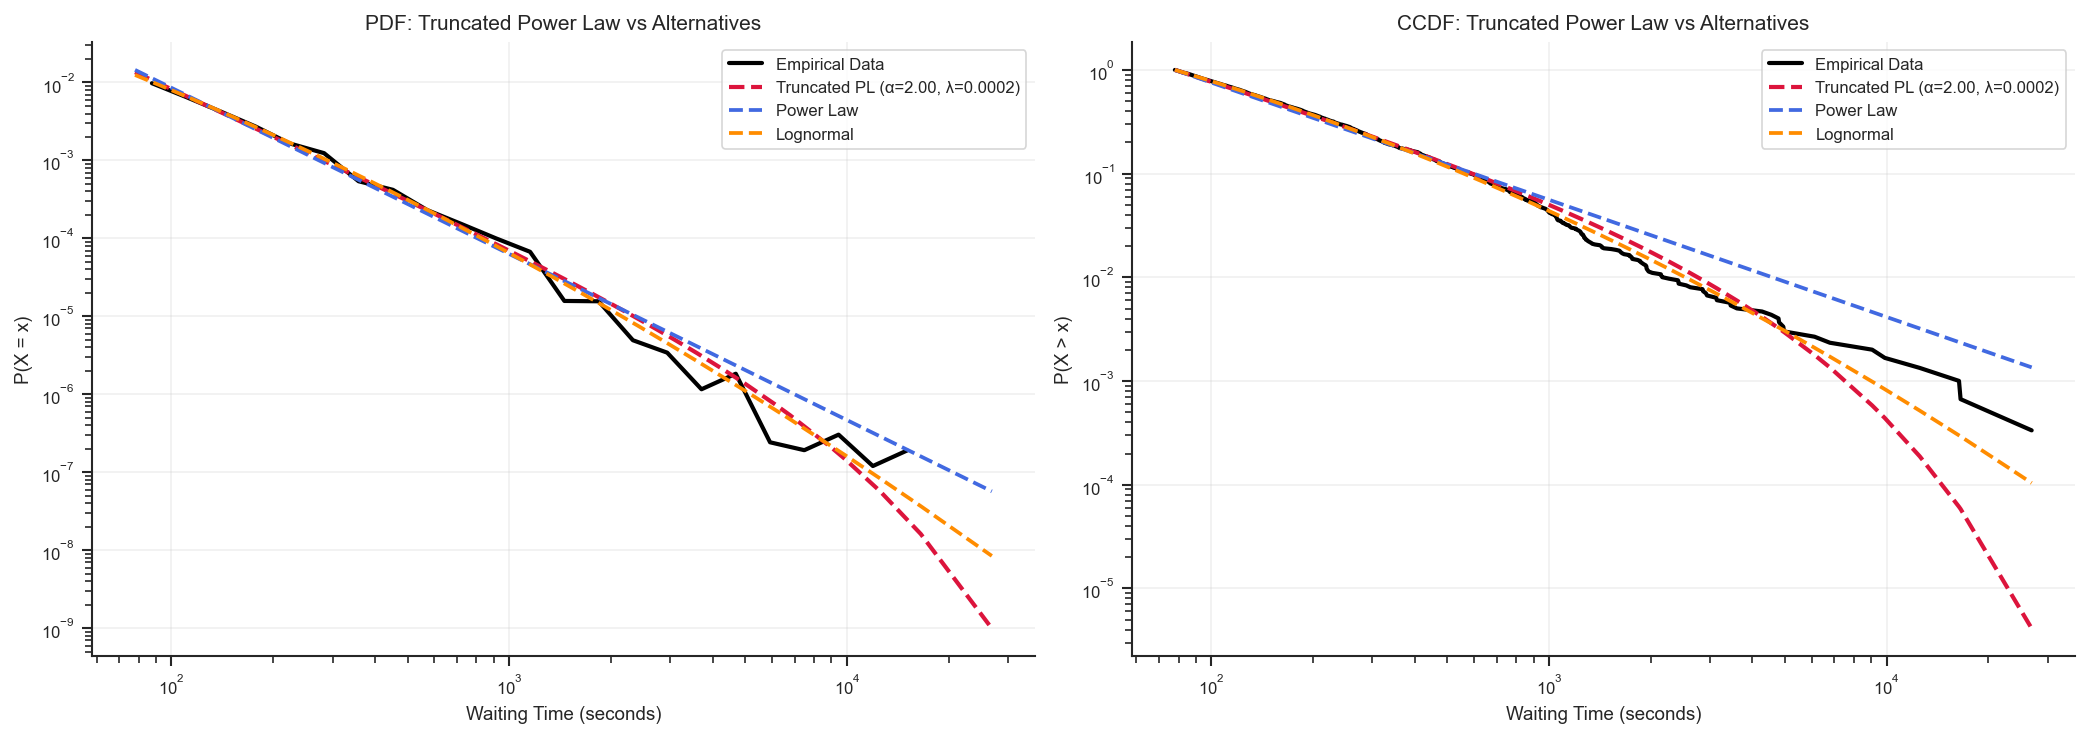

KS statistic (tail): 0.019511
KS p-value (tail): 0.202287


In [ ]:
import powerlaw

# Prepare data
data_tpl_w = np.asarray(waiting_times_w.values, dtype=float)
data_tpl_w = data_tpl_w[np.isfinite(data_tpl_w)]
data_tpl_w = data_tpl_w[data_tpl_w > 0]

# Fit using powerlaw package
fit_tpl_w = powerlaw.Fit(data_tpl_w, discrete=False, verbose=False)
tpl_w = fit_tpl_w.truncated_power_law

alpha_tpl_w = getattr(tpl_w, "alpha", np.nan)
lambda_tpl_w = getattr(tpl_w, "Lambda", np.nan)
xmin_tpl_w = getattr(tpl_w, "xmin", np.nan)
sigma_tpl_w = getattr(tpl_w, "sigma", np.nan)

print("="*70)
print("TRUNCATED POWER LAW FIT RESULTS")
print("="*70)
print(f"alpha: {alpha_tpl_w:.4f}")
print(f"lambda: {lambda_tpl_w:.6f}")
print(f"xmin: {xmin_tpl_w:.4f}")
print(f"sigma: {sigma_tpl_w:.4f}")
n_tail_tpl_w = int(np.sum(data_tpl_w >= xmin_tpl_w))
print(f"Data points above xmin: {n_tail_tpl_w} / {len(data_tpl_w)} ({100 * n_tail_tpl_w / len(data_tpl_w):.2f}%)")

# Likelihood-ratio comparisons (positive R => first model preferred)
print("\n" + "="*70)
print("TRUNCATED POWER LAW COMPARISONS")
print("="*70)
comparisons = [
    ("truncated_power_law", "power_law", "Truncated PL vs Power Law"),
    ("truncated_power_law", "lognormal", "Truncated PL vs Lognormal"),
    ("truncated_power_law", "exponential", "Truncated PL vs Exponential"),
]

for d1, d2, label in comparisons:
    R, p = fit_tpl_w.distribution_compare(d1, d2, normalized_ratio=True)
    print(f"\n{label}:")
    print(f"  R = {R:.4f}, p = {p:.4f}")
    if p < 0.05:
        if R > 0:
            print("  ✓ Truncated power law is significantly better")
        else:
            print(f"  ✗ {d2.replace('_', ' ')} is significantly better")
    else:
        print("  ≈ No significant difference")

# Manual KS distance for truncated power law
tail_tpl_w = np.sort(data_tpl_w[data_tpl_w >= xmin_tpl_w])
if len(tail_tpl_w) == 0:
    ks_tpl_w = float("nan")
else:
    empirical_cdf_tpl_w = np.arange(1, len(tail_tpl_w) + 1) / len(tail_tpl_w)
    try:
        model_cdf_tpl_w = tpl_w.cdf(tail_tpl_w)
    except Exception:
        model_cdf_tpl_w = 1 - tpl_w.ccdf(tail_tpl_w)
    ks_tpl_w = np.max(np.abs(empirical_cdf_tpl_w - model_cdf_tpl_w))

print("\n" + "="*70)
print(f"KS distance (truncated power law): {ks_tpl_w:.4f}")
if np.isnan(ks_tpl_w):
    print("KS could not be computed (no data >= xmin).")
elif ks_tpl_w < 0.1:
    print("✓ Good fit (KS < 0.1)")
elif ks_tpl_w < 0.15:
    print("~ Moderate fit (0.1 ≤ KS < 0.15)")
else:
    print("✗ Poor fit (KS ≥ 0.15)")
print("="*70)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fit_tpl_w.plot_pdf(color='black', linewidth=2, label='Empirical Data', ax=axes[0])
tpl_w.plot_pdf(
    color='crimson', linestyle='--', linewidth=2,
    label=f'Truncated PL (α={alpha_tpl_w:.2f}, λ={lambda_tpl_w:.4f})', ax=axes[0]
 )
fit_tpl_w.power_law.plot_pdf(color='royalblue', linestyle='--', linewidth=1.8, label='Power Law', ax=axes[0])
fit_tpl_w.lognormal.plot_pdf(color='darkorange', linestyle='--', linewidth=1.8, label='Lognormal', ax=axes[0])
axes[0].set_xlabel('Waiting Time (seconds)')
axes[0].set_ylabel('P(X = x)')
axes[0].set_title('PDF: Truncated Power Law vs Alternatives')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

fit_tpl_w.plot_ccdf(color='black', linewidth=2, label='Empirical Data', ax=axes[1])
tpl_w.plot_ccdf(
    color='crimson', linestyle='--', linewidth=2,
    label=f'Truncated PL (α={alpha_tpl_w:.2f}, λ={lambda_tpl_w:.4f})', ax=axes[1]
 )
fit_tpl_w.power_law.plot_ccdf(color='royalblue', linestyle='--', linewidth=1.8, label='Power Law', ax=axes[1])
fit_tpl_w.lognormal.plot_ccdf(color='darkorange', linestyle='--', linewidth=1.8, label='Lognormal', ax=axes[1])
axes[1].set_xlabel('Waiting Time (seconds)')
axes[1].set_ylabel('P(X > x)')
axes[1].set_title('CCDF: Truncated Power Law vs Alternatives')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
# One-off: compute KS p-value for truncated power law tail fit
from scipy import stats

tail_tpl_w = np.sort(data_tpl_w[data_tpl_w >= xmin_tpl_w])
ks_stat_tpl_w, ks_p_tpl_w = stats.kstest(tail_tpl_w, tpl_w.cdf)
print("="*70)
print(f"KS statistic (tail): {ks_stat_tpl_w:.6f}")
print(f"KS p-value (tail): {ks_p_tpl_w:.6g}")
print("="*70)

### Normal power law

In [ ]:
# Fit to a power law (without truncation) for comparison
fit_pl_w = powerlaw.Fit(data_tpl_w, discrete=False, verbose=False)
alpha_pl_w = getattr(fit_pl_w.power_law, "alpha", np.nan)
xmin_pl_w = getattr(fit_pl_w.power_law, "xmin", np.nan)
print("="*70)
print("POWER LAW FIT RESULTS")
print("="*70)
print(f"alpha: {alpha_pl_w:.4f}")
print(f"xmin: {xmin_pl_w:.4f}")
n_tail_pl_w = int(np.sum(data_tpl_w >= xmin_pl_w))
print(f"Data points above xmin: {n_tail_pl_w} / {len(data_tpl_w)} ({100 * n_tail_pl_w / len(data_tpl_w):.2f}%)")


POWER LAW FIT RESULTS
alpha: 2.1306
xmin: 78.0000
Data points above xmin: 2991 / 12983 (23.04%)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')


In [ ]:
# KS test for power law fit
tail_pl_w = np.sort(data_tpl_w[data_tpl_w >= xmin_pl_w])
ks_stat_pl_w, ks_p_pl_w = stats.kstest(tail_pl_w, fit_pl_w.power_law.cdf)
print("\n" + "="*70)
print(f"KS statistic (power law tail): {ks_stat_pl_w:.6f}")
print(f"KS p-value (power law tail): {ks_p_pl_w:.6g}")
print("="*70)



KS statistic (power law tail): 0.036946
KS p-value (power law tail): 0.00055368


### log-normal distribution

In [ ]:
# Fit to lognormal for comparison
fit_ln_w = powerlaw.Fit(data_tpl_w, discrete=False, verbose=False)
alpha_ln_w = getattr(fit_ln_w.lognormal, "mu", np.nan)
sigma_ln_w = getattr(fit_ln_w.lognormal, "sigma", np.nan)
print("\n" + "="*70)
print("LOGNORMAL FIT RESULTS")
print("="*70)
print(f"mu: {alpha_ln_w:.4f}")
print(f"sigma: {sigma_ln_w:.4f}")
print(f"Data points above lognormal xmin: {len(data_tpl_w)} / {len(data_tpl_w)} (100.00%)")
print("="*70)

# KS test for lognormal fit
tail_ln_w = np.sort(data_tpl_w)
ks_stat_ln_w, ks_p_ln_w = stats.kstest(tail_ln_w, fit_ln_w.lognormal.cdf)
print("\n" + "="*70)
print(f"KS statistic (lognormal): {ks_stat_ln_w:.6f}")
print(f"KS p-value (lognormal): {ks_p_ln_w:.6g}")
print("="*70)


LOGNORMAL FIT RESULTS
mu: 0.9123
sigma: 2.1087
Data points above lognormal xmin: 12983 / 12983 (100.00%)

KS statistic (lognormal): 0.014769
KS p-value (lognormal): 0.00686801


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
